<a href="https://colab.research.google.com/github/prateekP1906/AML-LAB/blob/main/AML_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")


Dataset shape: (569, 31) (Rows: 569, Columns: 31)


In [17]:

X = data.data.values
y = data.target.values

print(f"Features (X) isolated! Shape: {X.shape}")
print(f"Diagnosis (y) isolated! Shape: {y.shape}")


Features (X) isolated! Shape: (569, 30)
Diagnosis (y) isolated! Shape: (569,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print(f"Training data size: {X_train.shape[0]}")
print(f"Testing data size: {X_test.shape[0]}")

Training data size: 398
Testing data size: 171


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Data pre-processing (scaling) complete!")

Data pre-processing (scaling) complete!


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

dt_model = DecisionTreeClassifier()
lr_model = LogisticRegression()

dt_model.fit(X_train_scaled, Y_train)
lr_model.fit(X_train_scaled, Y_train)

print("Both Decision Tree and Logistic Regression models have have trained!")

Both Decision Tree and Logistic Regression models have have trained!


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

dt_predictions = dt_model.predict(X_test_scaled)
lr_predictions = lr_model.predict(X_test_scaled)

dc_acc = accuracy_score(Y_test, dt_predictions)
dc_prec = precision_score(Y_test, dt_predictions)
dc_rec = recall_score(Y_test, dt_predictions)
dc_f1 = f1_score(Y_test, dt_predictions)

lr_acc = accuracy_score(Y_test, lr_predictions)
lr_prec = precision_score(Y_test, lr_predictions)
lr_rec = recall_score(Y_test, lr_predictions)
lr_f1 = f1_score(Y_test, lr_predictions)

results_table = pd.DataFrame({
    "Metric" : ["Accuracy", "Precision", "Recall", "F1_score"],
    "Decision Tree" : [dc_acc, dc_prec, dc_rec, dc_f1],
    "Logistic Regression" : [lr_acc, lr_prec, lr_rec, lr_f1]
})

results_table = results_table.round(4)

display(results_table)

,Metric,Decision Tree,Logistic Regression
0,Accuracy,0.9357,0.9825
1,Precision,0.9619,0.9907
2,Recall,0.9352,0.9815
3,F1_score,0.9484,0.9860


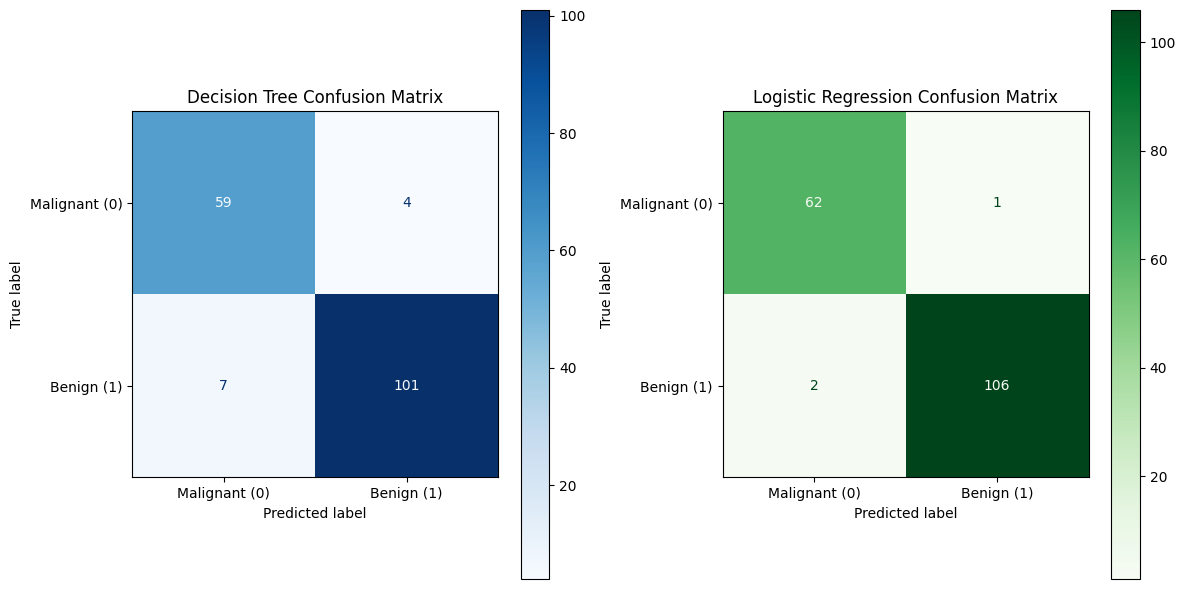

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ConfusionMatrixDisplay.from_predictions(
    Y_test,
    dt_predictions,
    display_labels=["Malignant (0)", "Benign (1)"],
    cmap="Blues",
    ax = axes[0]
)

axes[0].set_title("Decision Tree Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    Y_test,
    lr_predictions,
    display_labels=["Malignant (0)", "Benign (1)"],
    cmap="Greens",
    ax = axes[1]
)

axes[1].set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()
